# PowerGrid Bharat — Data Cleaning, Time Series & Forecasting
**Local Jupyter version** — pandas + matplotlib. Same logic as Databricks notebook.

Ensure these files are in the same directory (or update paths):
- `daily-power-generation.csv` (276 MB)
- `daily-renewable-energy-generation.csv`
- `energy-requirement-and-availabililty.csv`


In [0]:

%pip install chronos-forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 134.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.7/419.7 MB 156.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.8/433.8 MB 152.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.8/220.8 MB 181.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.6/196.6 MB 175.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 MB 180.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 MB 147.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.9/542.9 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 133.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 139.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
dbutils.library.restartPython()

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 40)


## 1. Load Raw Data

In [0]:
# Update paths if your files are elsewhere
DATA_DIR = "/Workspace/Users/mpriyabrata@iisc.ac.in"
#pg = pd.read_csv("daily-power-generation.csv", dtype={"state_code": str})
#re = pd.read_csv("daily-renewable-energy-generation.csv", dtype={"state_code": str})
#ds = pd.read_csv("energy-requirement-and-availabililty.csv", dtype={"state_code": str})
pg = pd.read_csv(f"{DATA_DIR}/daily-power-generation.csv", dtype={"state_code": str})
re = pd.read_csv(f"{DATA_DIR}/daily-renewable-energy-generation.csv", dtype={"state_code": str})
ds = pd.read_csv(f"{DATA_DIR}/energy-requirement-and-availabililty.csv", dtype={"state_code": str})

print(f"Power Gen:     {pg.shape}")
print(f"Renewable:     {re.shape}")
print(f"Demand/Supply: {ds.shape}")

Power Gen:     (2477946, 12)
Renewable:     (61764, 9)
Demand/Supply: (1579, 6)


## 2. Cleaning — Report & Fix Nulls

In [0]:
# ========================================
# 2a. POWER GENERATION — Report nulls
# ========================================
print("=" * 50)
print("POWER GENERATION — NULLS BEFORE CLEANING")
print("=" * 50)
null_report = pg.isnull().sum()
print(null_report[null_report > 0])

# What are the null rows?
pg_nulls = pg[pg[["sector", "station_type"]].isnull().any(axis=1)]
print(f"\nNull sector/station_type: {len(pg_nulls)} rows")
print("These are Bhutan import rows:")
print(pg_nulls[["date", "region", "state_name", "power_station"]].drop_duplicates("power_station").to_string(index=False))

# What stations have null capacity?
mc_nulls = pg[pg["monitored_capacity"].isnull()]
print(f"\nNull monitored_capacity: {len(mc_nulls)} rows across {mc_nulls.power_station.nunique()} stations:")
print(mc_nulls[["date", "state_name", "power_station", "station_type"]].drop_duplicates("power_station").to_string(index=False))


POWER GENERATION — NULLS BEFORE CLEANING
monitored_capacity    13260
todays_gen_prgm           3
todays_gen_act            3
dtype: int64

Null sector/station_type: 0 rows
These are Bhutan import rows:
Empty DataFrame
Columns: [date, region, state_name, power_station]
Index: []

Null monitored_capacity: 13260 rows across 21 stations:
      date        state_name         power_station station_type
2017-11-27       Maharashtra                  Stps      Thermal
2022-02-13     Uttar Pradesh         Ghatampur Tpp      Thermal
2022-02-13         Telangana        Telangana Stpp      Thermal
2022-02-13         Jharkhand   North Karanpura Tpp      Thermal
2022-02-14     Uttar Pradesh           Obra-C Stpp      Thermal
2022-02-14     Uttar Pradesh         Panki Tps Ext      Thermal
2022-02-14        Tamil Nadu          Ennore Sctpp      Thermal
2022-02-14         Telangana           Yadadri Tps      Thermal
2022-02-14 Arunachal Pradesh   Lower Subansiri Hep        Hydro
2022-03-24       Maharas

In [0]:
# ========================================
# 2a. POWER GENERATION — Fix nulls
# ========================================
pg["date"] = pd.to_datetime(pg["date"])

# Tag Bhutan imports
pg["sector"] = pg["sector"].fillna("Import")
pg["station_type"] = pg["station_type"].fillna("Import")
pg["state_code"] = pg["state_code"].fillna("IMP")

# Fill capacity with station median, then 0
pg["monitored_capacity"] = pg.groupby("power_station")["monitored_capacity"].transform(
    lambda x: x.fillna(x.median())
)
pg["monitored_capacity"] = pg["monitored_capacity"].fillna(0)

# Fill gen nulls (only 3 each)
pg["todays_gen_prgm"] = pg["todays_gen_prgm"].fillna(0)
pg["todays_gen_act"] = pg["todays_gen_act"].fillna(0)

# Derived columns
pg["gen_deviation"] = pg["todays_gen_act"] - pg["todays_gen_prgm"]
pg["year"] = pg["date"].dt.year
pg["month"] = pg["date"].dt.month
pg["day_of_week"] = pg["date"].dt.day_name()
pg["week_of_year"] = pg["date"].dt.isocalendar().week.astype(int)

print(f"✅ Power Gen cleaned: {pg.shape}, remaining nulls: {pg.isnull().sum().sum()}")


✅ Power Gen cleaned: (2477946, 17), remaining nulls: 0


In [0]:
# ========================================
# 2b. RENEWABLE — Report & Fix
# ========================================
print("=" * 50)
print("RENEWABLE — NULLS BEFORE CLEANING")
print("=" * 50)
null_report = re.isnull().sum()
print(null_report[null_report > 0])

re_null_region = re[re["region"].isnull()]
print(f"\nNull region rows are all: {re_null_region.state_name.unique()}")

# Fix
re["date"] = pd.to_datetime(re["date"])
region_map = re.dropna(subset=["region"]).drop_duplicates("state_name").set_index("state_name")["region"].to_dict()
re["region"] = re["state_name"].map(region_map)
re.loc[re["state_name"] == "All India", "region"] = "All India"
re["solar_energy"] = re["solar_energy"].fillna(0)
re["other_renewable_energy"] = re["other_renewable_energy"].fillna(0)
re["region_short"] = re["region"].str.replace(" Region", "", regex=False)

print(f"\n✅ Renewable cleaned: {re.shape}, remaining nulls: {re.isnull().sum().sum()}")


RENEWABLE — NULLS BEFORE CLEANING
solar_energy              1
other_renewable_energy    4
dtype: int64

Null region rows are all: []

✅ Renewable cleaned: (61764, 10), remaining nulls: 0


In [0]:
# ========================================
# 2c. DEMAND/SUPPLY — Report & Fix
# ========================================
print("=" * 50)
print("DEMAND/SUPPLY — NULLS BEFORE CLEANING")
print("=" * 50)
null_report = ds.isnull().sum()
print(null_report[null_report > 0])
print(f"Null state_code states: {ds[ds['state_code'].isnull()].state_name.unique()}")

ds["month"] = pd.to_datetime(ds["month"])
ds["state_code"] = ds["state_code"].fillna("NA")
ds = ds.rename(columns={"energy_requirement": "demand_mu", "energy_availability": "supply_mu"})
ds["deficit_mu"] = (ds["demand_mu"] - ds["supply_mu"]).round(3)
ds["deficit_pct"] = ((ds["demand_mu"] - ds["supply_mu"]) / ds["demand_mu"] * 100).round(2)

# Grid region mapping
grid_region_map = {
    "Chandigarh": "Northern", "Delhi": "Northern", "Haryana": "Northern",
    "Himachal Pradesh": "Northern", "UTs of J&K and Ladakh": "Northern",
    "Punjab": "Northern", "Rajasthan": "Northern", "Uttar Pradesh": "Northern",
    "Uttarakhand": "Northern",
    "Chhattisgarh": "Western", "Gujarat": "Western", "Madhya Pradesh": "Western",
    "Maharashtra": "Western", "Dadra & Nagar Haveli and Daman & Diu": "Western",
    "Goa": "Western",
    "Andhra Pradesh": "Southern", "Telangana": "Southern", "Karnataka": "Southern",
    "Kerala": "Southern", "Tamil Nadu": "Southern", "Puducherry": "Southern",
    "Lakshadweep": "Southern",
    "Bihar": "Eastern", "DVC": "Eastern", "Jharkhand": "Eastern",
    "Odisha": "Eastern", "West Bengal": "Eastern", "Sikkim": "Eastern",
    "Andaman- Nicobar": "Eastern",
    "Arunachal Pradesh": "North-Eastern", "Assam": "North-Eastern",
    "Manipur": "North-Eastern", "Meghalaya": "North-Eastern",
    "Mizoram": "North-Eastern", "Nagaland": "North-Eastern",
    "Tripura": "North-Eastern",
}
ds["grid_region"] = ds["state_name"].map(grid_region_map)

print(f"\n✅ Demand/Supply cleaned: {ds.shape}, remaining nulls: {ds.isnull().sum().sum()}")


DEMAND/SUPPLY — NULLS BEFORE CLEANING
Series([], dtype: int64)
Null state_code states: []

✅ Demand/Supply cleaned: (1579, 9), remaining nulls: 0


## 3. Time Series Aggregations

In [0]:
# ========================================
# 3a. Daily All India (conventional gen)
# ========================================
pg_india = pg[pg["region"] != "Bhutan Imp."]

daily_india = (
    pg_india.groupby("date")
    .agg(
        total_gen_actual=("todays_gen_act", "sum"),
        total_gen_programmed=("todays_gen_prgm", "sum"),
        total_capacity=("monitored_capacity", "sum"),
        active_stations=("power_station", "nunique"),
    )
    .reset_index()
)

# Merge All India renewable
re_india = re[re["state_name"] == "All India"][["date", "wind_energy", "solar_energy", "other_renewable_energy", "total_renewable_energy"]]
daily_india = daily_india.merge(re_india, on="date", how="left")

# Derived
daily_india["total_generation"] = daily_india["total_gen_actual"] + daily_india["total_renewable_energy"].fillna(0)
daily_india["renewable_share_pct"] = (
    daily_india["total_renewable_energy"].fillna(0) / daily_india["total_generation"] * 100
).round(2)
daily_india["gen_deviation_pct"] = (
    (daily_india["total_gen_actual"] - daily_india["total_gen_programmed"])
    / daily_india["total_gen_programmed"].replace(0, np.nan) * 100
).round(2)

print(f"✅ Daily India: {daily_india.shape}")
daily_india.tail()


✅ Daily India: (2550, 12)


,date,total_gen_actual,total_gen_programmed,total_capacity,active_stations,wind_energy,solar_energy,other_renewable_energy,total_renewable_energy,total_generation,renewable_share_pct,gen_deviation_pct
2545,2024-11-07,4095.64,4260.87,299075.09,526,79.50,363.06,26.34,468.90,4564.54,10.27,-3.88
2546,2024-11-08,4124.04,4256.77,299075.09,526,82.78,352.11,26.85,461.74,4585.78,10.07,-3.12
2547,2024-11-09,4122.92,4256.77,299075.09,526,82.87,356.17,28.45,467.49,4590.41,10.18,-3.14
2548,2024-11-10,3940.29,4202.22,299075.09,526,85.63,368.87,28.45,482.95,4423.24,10.92,-6.23
2549,2024-11-11,4103.89,4186.97,299075.09,526,84.09,373.08,28.72,485.89,4589.78,10.59,-1.98


In [0]:
# ========================================
# 3b. Daily State level + renewable merge
# ========================================
daily_state = (
    pg_india.groupby(["date", "region", "state_name"])
    .agg(
        gen_actual=("todays_gen_act", "sum"),
        gen_programmed=("todays_gen_prgm", "sum"),
        capacity=("monitored_capacity", "sum"),
    )
    .reset_index()
)

re_states = re[re["state_name"] != "All India"][["date", "state_name", "wind_energy", "solar_energy", "other_renewable_energy", "total_renewable_energy"]]
daily_state = daily_state.merge(re_states, on=["date", "state_name"], how="left")
daily_state["total_gen_with_re"] = daily_state["gen_actual"] + daily_state["total_renewable_energy"].fillna(0)

print(f"✅ Daily State: {daily_state.shape}")
print(f"Rows with renewable data: {daily_state['total_renewable_energy'].notna().sum()} ({daily_state['total_renewable_energy'].notna().mean()*100:.1f}%)")


✅ Daily State: (83974, 11)
Rows with renewable data: 52238 (62.2%)


In [0]:
# ========================================
# 3c. Weekly aggregation
# ========================================
daily_india["year"] = daily_india["date"].dt.year
daily_india["week"] = daily_india["date"].dt.isocalendar().week.astype(int)

weekly = (
    daily_india.groupby(["year", "week"])
    .agg(
        week_start=("date", "min"),
        avg_daily_gen=("total_gen_actual", "mean"),
        max_daily_gen=("total_gen_actual", "max"),
        min_daily_gen=("total_gen_actual", "min"),
        volatility=("total_gen_actual", "std"),
        avg_renewable=("total_renewable_energy", "mean"),
        avg_renewable_pct=("renewable_share_pct", "mean"),
    )
    .reset_index()
    .sort_values(["year", "week"])
)

print(f"✅ Weekly: {weekly.shape}")
weekly.tail()


✅ Weekly: (368, 9)


,year,week,week_start,avg_daily_gen,max_daily_gen,min_daily_gen,volatility,avg_renewable,avg_renewable_pct
363,2024,42,2024-10-14,4246.911429,4312.33,4086.58,78.389334,432.984286,9.247143
364,2024,43,2024-10-21,4156.655714,4262.90,4009.76,95.753193,462.775714,10.027143
365,2024,44,2024-10-28,3940.654286,4363.60,3580.27,363.104695,459.885714,10.500000
366,2024,45,2024-11-04,4029.637143,4124.04,3872.95,97.696874,468.932857,10.425714
367,2024,46,2024-11-11,4103.890000,4103.89,4103.89,NaN,485.890000,10.590000


In [0]:
# ========================================
# 3d. Monthly aggregation
# ========================================
daily_india["month_start"] = daily_india["date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    daily_india.groupby("month_start")
    .agg(
        avg_daily_gen=("total_gen_actual", "mean"),
        total_gen=("total_gen_actual", "sum"),
        avg_renewable=("total_renewable_energy", "mean"),
        avg_renewable_pct=("renewable_share_pct", "mean"),
        days=("date", "count"),
    )
    .reset_index()
)

print(f"✅ Monthly: {monthly.shape}")
monthly.tail(12)


✅ Monthly: (85, 6)


,month_start,avg_daily_gen,total_gen,avg_renewable,avg_renewable_pct,days
73,2023-12-01,3739.636774,115928.74,442.164839,10.596129,31
74,2024-01-01,4121.561613,127768.41,420.479355,9.268065,31
75,2024-02-01,4080.090000,118322.61,521.658276,11.330345,29
76,2024-03-01,4175.525484,129441.29,540.599677,11.481613,31
77,2024-04-01,4523.529667,135705.89,552.564000,10.879667,30
78,2024-05-01,4654.186774,144279.79,666.870000,12.483548,31
79,2024-06-01,4622.594667,138677.84,718.213333,13.441000,30
80,2024-07-01,4294.512258,133129.88,781.687097,15.425806,31
81,2024-08-01,4224.486129,130959.07,643.433871,13.275484,31
82,2024-09-01,4250.170333,127505.11,675.254000,13.738000,30


In [0]:
# ========================================
# 3e. Station-level summary
# ========================================
station_summary = (
    pg.groupby(["power_station", "state_name", "station_type", "sector", "region"])
    .agg(
        total_gen=("todays_gen_act", "sum"),
        avg_daily_gen=("todays_gen_act", "mean"),
        avg_capacity_mw=("monitored_capacity", "mean"),
        days_active=("date", "nunique"),
        first_seen=("date", "min"),
        last_seen=("date", "max"),
    )
    .reset_index()
    .sort_values("total_gen", ascending=False)
)

print(f"✅ Station summary: {station_summary.shape[0]} stations")
station_summary.head(15)


✅ Station summary: 612 stations


,power_station,state_name,station_type,sector,region,total_gen,avg_daily_gen,avg_capacity_mw,days_active,first_seen,last_seen
601,Vindhyachal Stps,Madhya Pradesh,Thermal,Central,Western,257884.01,7.779306,366.153846,2550,2017-09-01,2024-11-11
488,Sasan Umtpp,Madhya Pradesh,Thermal,Private,Western,225961.62,14.768733,660.000000,2550,2017-09-01,2024-11-11
464,Rihand Stps,Uttar Pradesh,Thermal,Central,Northern,161927.11,10.583471,500.000000,2550,2017-09-01,2024-11-11
514,Sipat Stps,Chhatisgarh,Thermal,Central,Western,156157.93,12.247681,596.000000,2550,2017-09-01,2024-11-11
538,Talcher Stps,Odisha,Thermal,Central,Eastern,152070.12,9.939224,500.000000,2550,2017-09-01,2024-11-11
353,Mundra Umtpp,Gujarat,Thermal,Private,Western,145880.01,11.441569,800.000000,2550,2017-09-01,2024-11-11
249,Korba Stps,Chhatisgarh,Thermal,Central,Western,143018.42,8.012236,371.428571,2550,2017-09-01,2024-11-11
24,Anpara Tps,Uttar Pradesh,Thermal,State,Northern,122924.37,6.886519,375.714286,2550,2017-09-01,2024-11-11
560,Tirora Tps,Maharashtra,Thermal,Private,Western,122229.37,11.471550,660.000000,2131,2017-09-01,2023-09-19
450,Ramagundem Stps,Telangana,Thermal,Central,Southern,120181.60,6.732863,371.428571,2550,2017-09-01,2024-11-11


## 4. Time Series Plots

### 4a. Daily Generation — Full Timeline

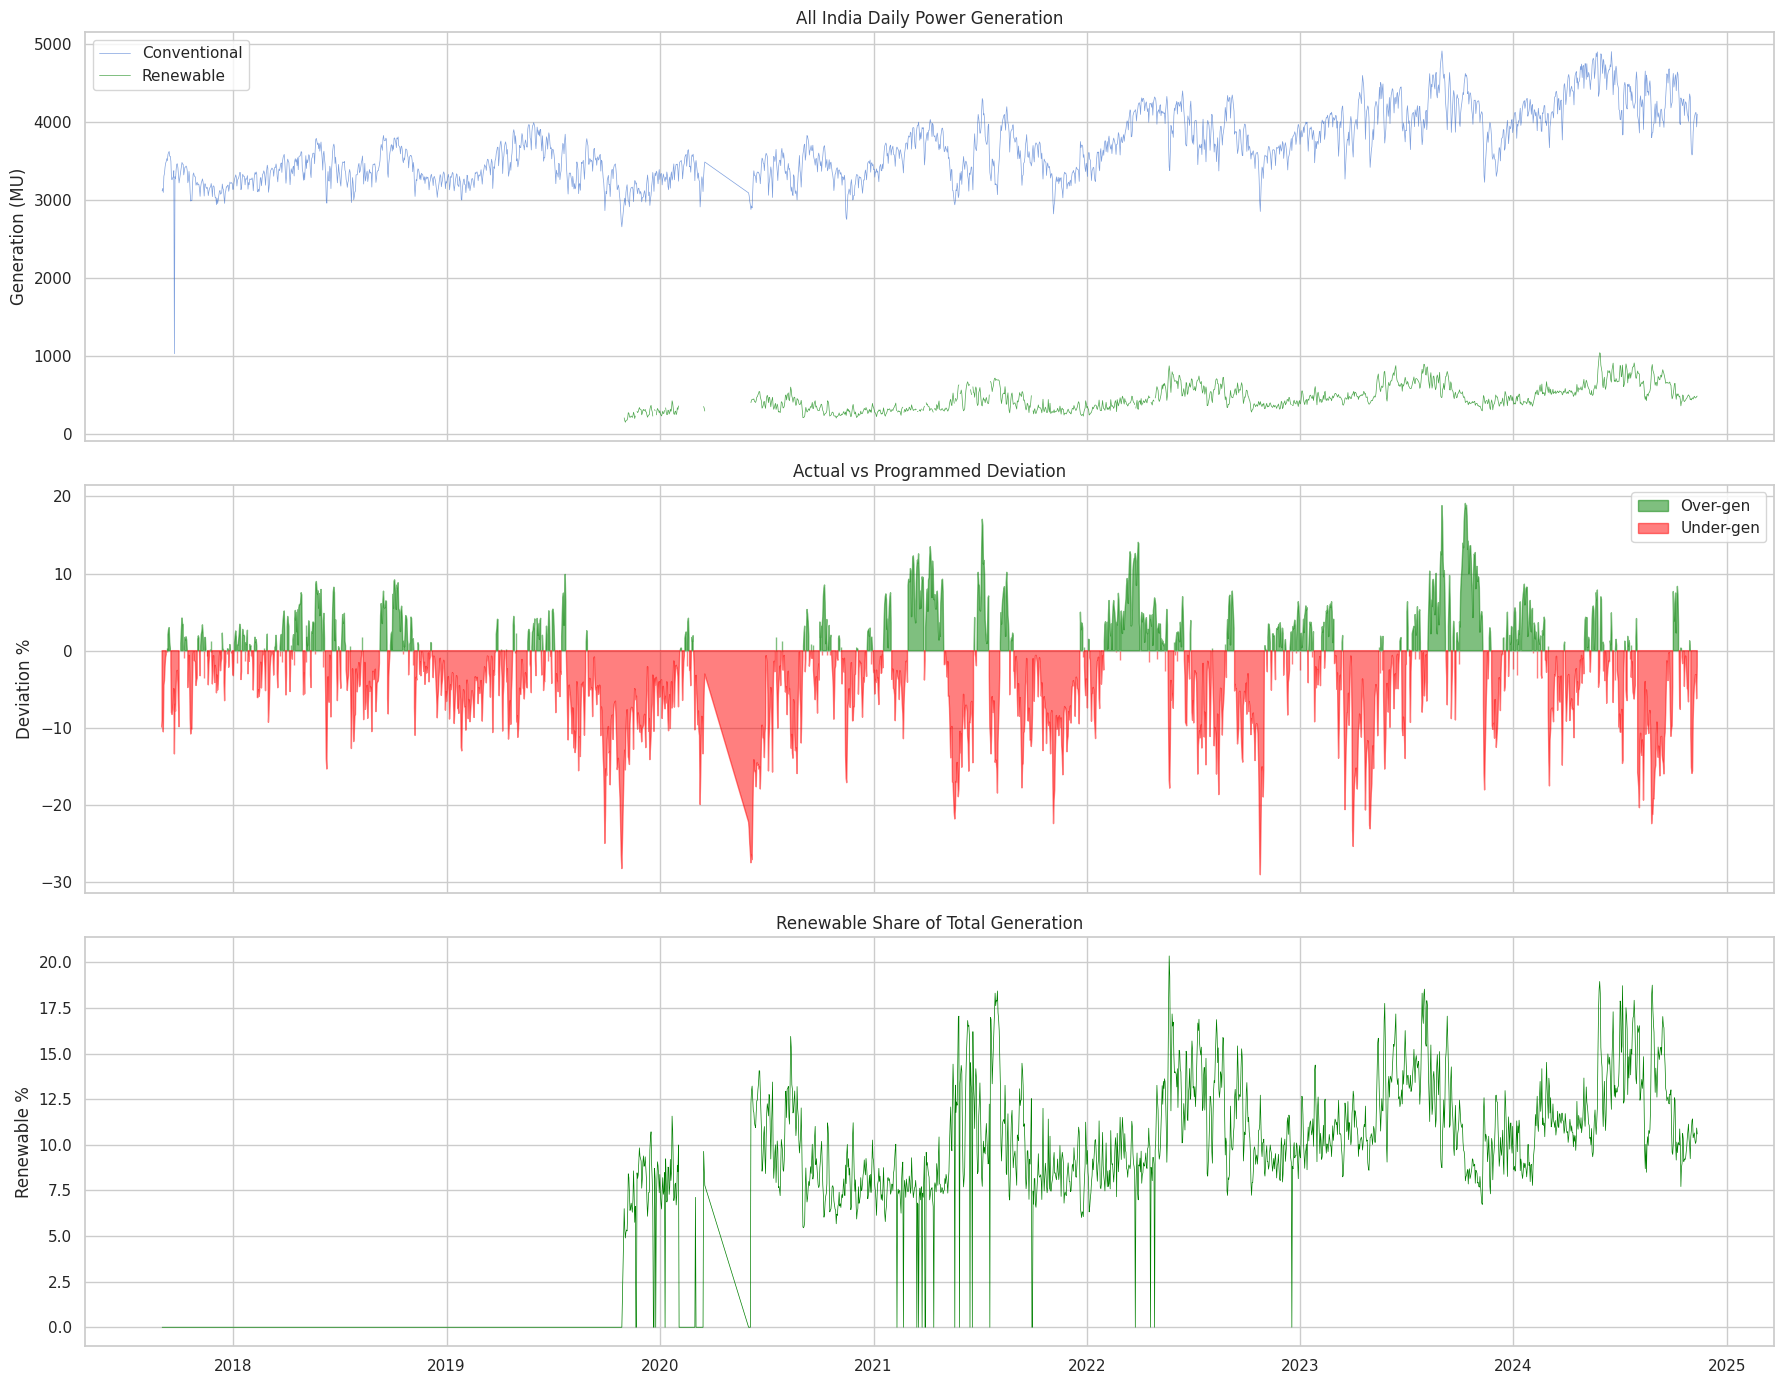

In [0]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# Total generation
axes[0].plot(daily_india["date"], daily_india["total_gen_actual"], linewidth=0.5, alpha=0.7, label="Conventional")
axes[0].plot(daily_india["date"], daily_india["total_renewable_energy"], linewidth=0.5, alpha=0.7, color="green", label="Renewable")
axes[0].set_ylabel("Generation (MU)")
axes[0].set_title("All India Daily Power Generation")
axes[0].legend()

# Deviation
axes[1].fill_between(daily_india["date"], daily_india["gen_deviation_pct"], 0, alpha=0.5,
                     where=daily_india["gen_deviation_pct"] >= 0, color="green", label="Over-gen")
axes[1].fill_between(daily_india["date"], daily_india["gen_deviation_pct"], 0, alpha=0.5,
                     where=daily_india["gen_deviation_pct"] < 0, color="red", label="Under-gen")
axes[1].set_ylabel("Deviation %")
axes[1].set_title("Actual vs Programmed Deviation")
axes[1].legend()

# Renewable share
re_mask = daily_india["renewable_share_pct"].notna()
axes[2].plot(daily_india.loc[re_mask, "date"], daily_india.loc[re_mask, "renewable_share_pct"],
             linewidth=0.5, color="green")
axes[2].set_ylabel("Renewable %")
axes[2].set_title("Renewable Share of Total Generation")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


### 4b. Weekly Volatility

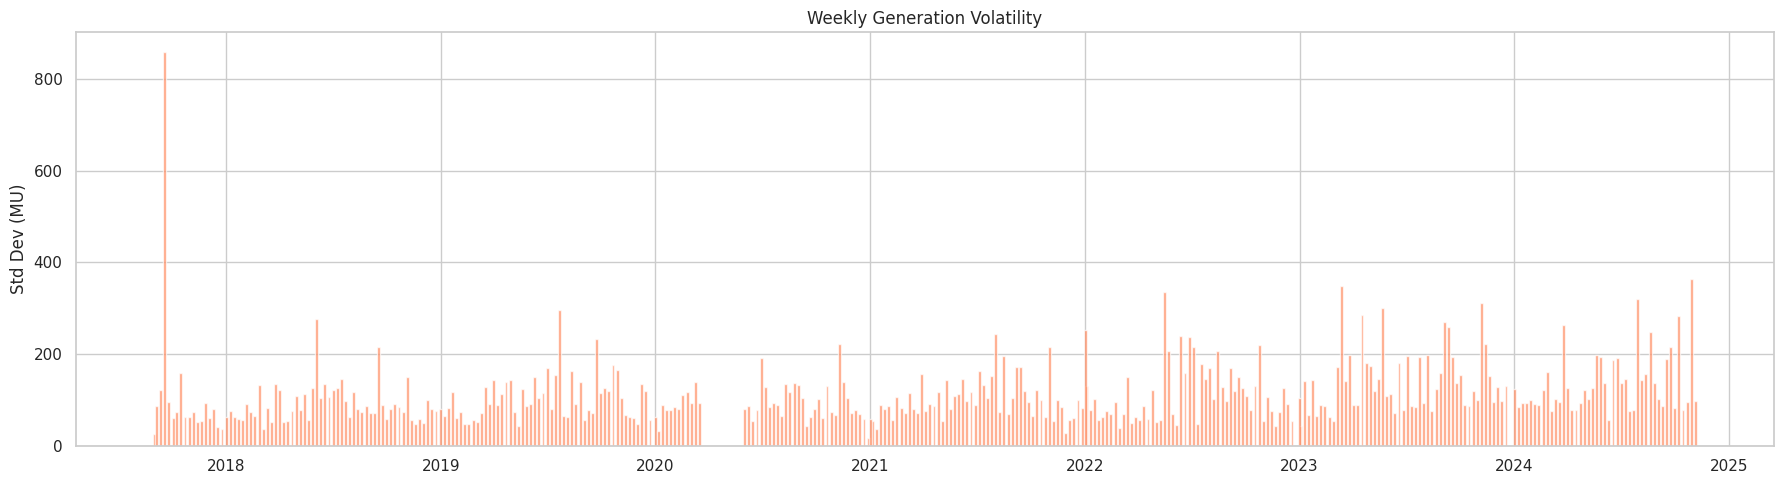

In [0]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(weekly["week_start"], weekly["volatility"], width=5, alpha=0.7, color="coral")
ax.set_ylabel("Std Dev (MU)")
ax.set_title("Weekly Generation Volatility")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


### 4c. Monthly Trend + Renewable Overlay

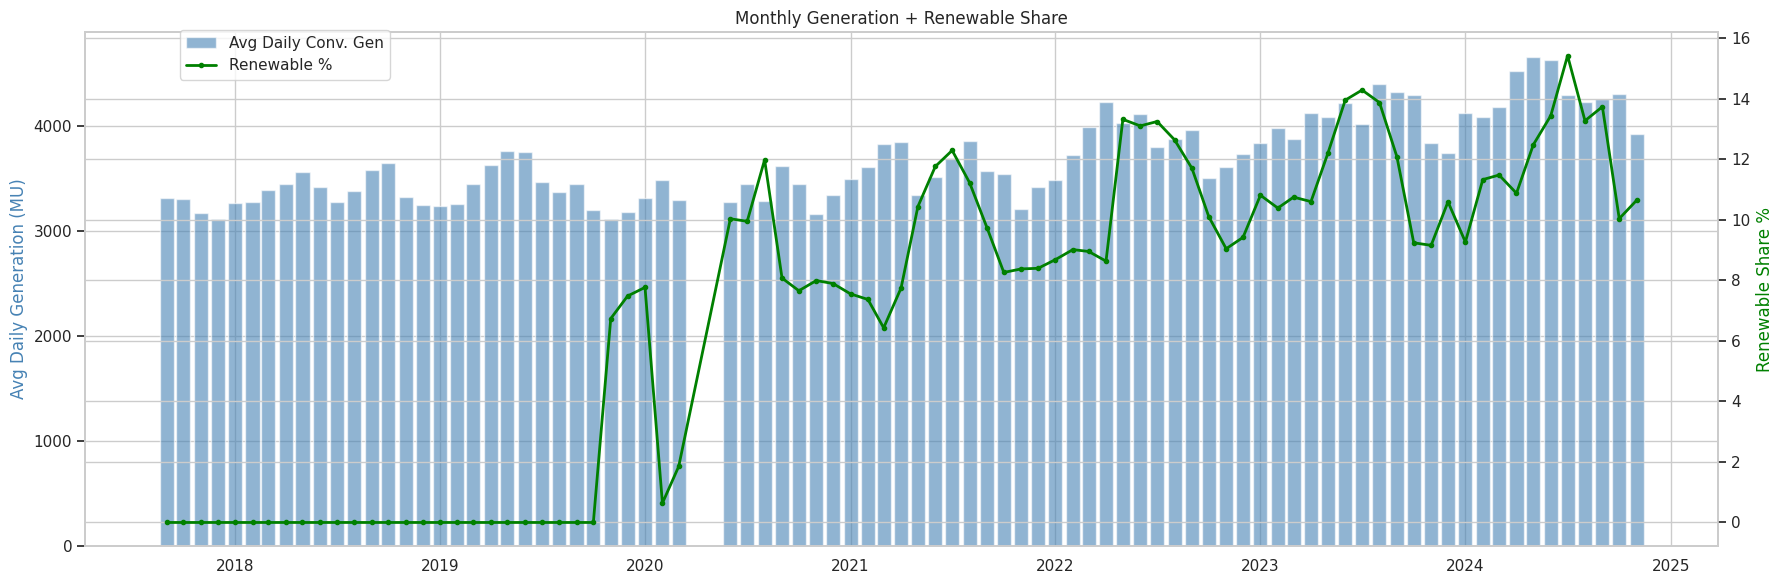

In [0]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.bar(monthly["month_start"], monthly["avg_daily_gen"], width=25, alpha=0.6, label="Avg Daily Conv. Gen", color="steelblue")
ax1.set_ylabel("Avg Daily Generation (MU)", color="steelblue")

ax2 = ax1.twinx()
re_mask = monthly["avg_renewable_pct"].notna()
ax2.plot(monthly.loc[re_mask, "month_start"], monthly.loc[re_mask, "avg_renewable_pct"],
         color="green", linewidth=2, marker="o", markersize=3, label="Renewable %")
ax2.set_ylabel("Renewable Share %", color="green")

ax1.set_title("Monthly Generation + Renewable Share")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()


### 4d. Day-of-Week Pattern

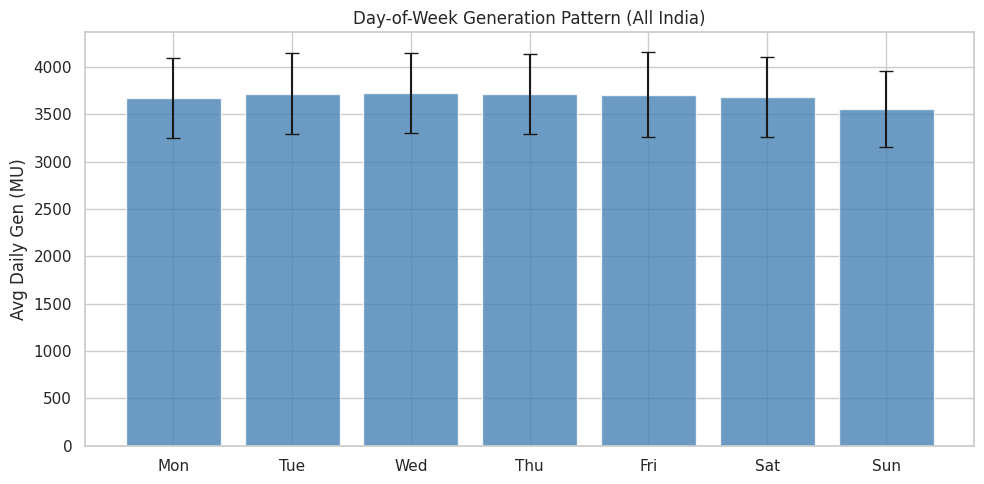

In [0]:
daily_india["dow"] = daily_india["date"].dt.dayofweek  # 0=Mon
dow_avg = daily_india.groupby("dow")["total_gen_actual"].agg(["mean", "std"]).reset_index()
dow_avg["label"] = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dow_avg["label"], dow_avg["mean"], yerr=dow_avg["std"], capsize=5, color="steelblue", alpha=0.8)
ax.set_ylabel("Avg Daily Gen (MU)")
ax.set_title("Day-of-Week Generation Pattern (All India)")
plt.tight_layout()
plt.show()


### 4e. Station Type & Sector Breakdown

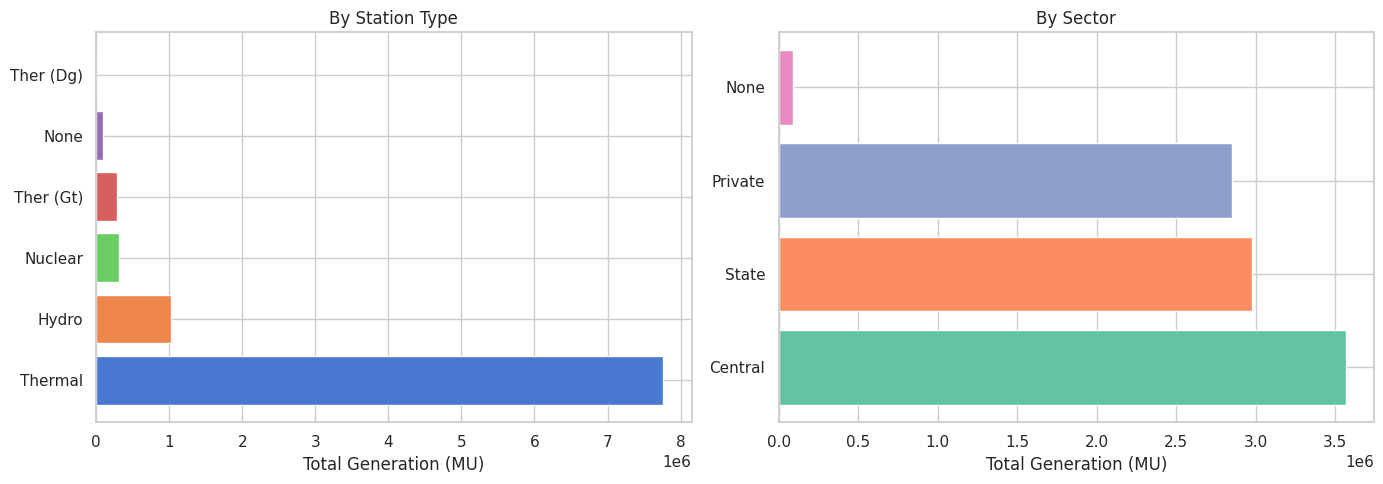

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_type = station_summary.groupby("station_type")["total_gen"].sum().sort_values(ascending=False)
axes[0].barh(by_type.index, by_type.values, color=sns.color_palette("muted", len(by_type)))
axes[0].set_xlabel("Total Generation (MU)")
axes[0].set_title("By Station Type")

by_sector = station_summary.groupby("sector")["total_gen"].sum().sort_values(ascending=False)
axes[1].barh(by_sector.index, by_sector.values, color=sns.color_palette("Set2", len(by_sector)))
axes[1].set_xlabel("Total Generation (MU)")
axes[1].set_title("By Sector")

plt.tight_layout()
plt.show()


### 4f. State × Month Heatmap

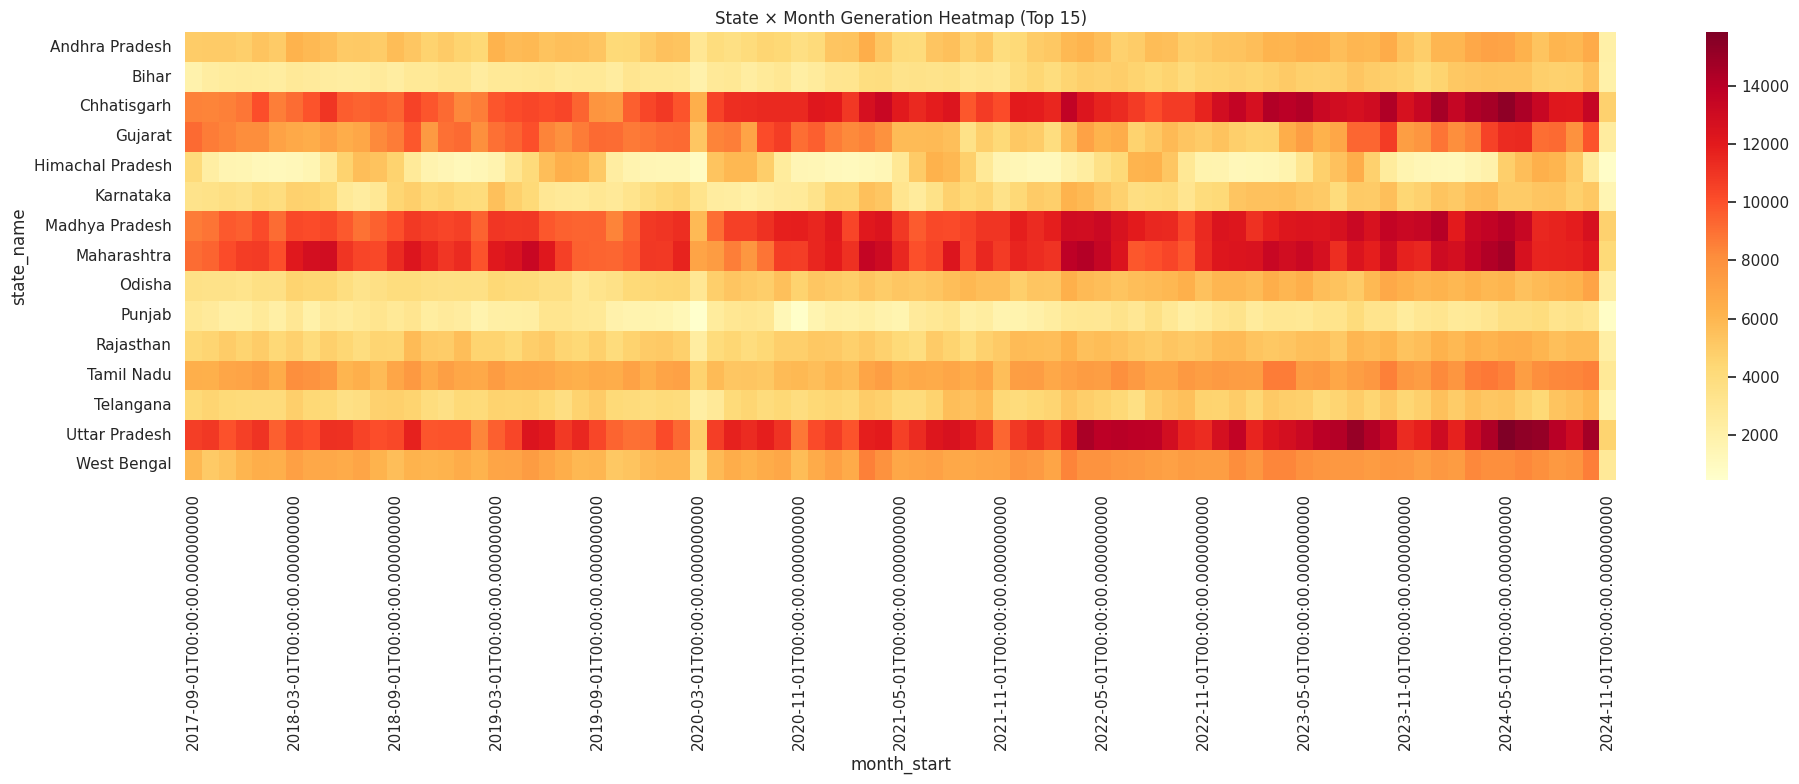

In [0]:
state_monthly = (
    daily_state.assign(month_start=daily_state["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month_start", "state_name"])["gen_actual"].sum()
    .reset_index()
)

top_states = state_monthly.groupby("state_name")["gen_actual"].sum().nlargest(15).index
pivot = state_monthly[state_monthly["state_name"].isin(top_states)].pivot_table(
    index="state_name", columns="month_start", values="gen_actual", aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, xticklabels=6)
ax.set_title("State × Month Generation Heatmap (Top 15)")
plt.tight_layout()
plt.show()


## 5. Chronos Forecasting
Amazon Chronos-T5-Small (~46M params, ~200MB RAM).

```bash
pip install amazon-chronos[inference] torch
```


In [0]:
import torch
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
print("✅ Chronos loaded")

ts_df = daily_india[["date", "total_gen_actual"]].rename(
    columns={"date": "timestamp", "total_gen_actual": "target"}
)
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"])
ts_df = ts_df.sort_values("timestamp")
ts_df = ts_df.set_index("timestamp").asfreq("D").reset_index()
ts_df["target"] = ts_df["target"].interpolate()
ts_df["id"] = "all_india"

pred_df = pipeline.predict_df(
    ts_df,
    prediction_length=30,
    num_samples=20,
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

print(pred_df.columns.tolist())
print(pred_df.head())

✅ Chronos loaded
['id', 'timestamp', 'target_name', 'predictions', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']
          id  timestamp target_name  predictions          0.1          0.2  \
0  all_india 2024-11-12      target  4171.924316  4063.361328  4125.397461   
1  all_india 2024-11-13      target  4164.169434  3995.121338  4026.139404   
2  all_india 2024-11-14      target  4126.948242  3908.270996  3988.917725   
3  all_india 2024-11-15      target  4117.642578  3926.881836  4001.324951   
4  all_india 2024-11-16      target  3995.121582  3715.959229  3889.660156   

           0.3          0.4          0.5          0.6          0.7  \
0  4125.397461  4156.415039  4171.923828  4187.433105  4218.451172   
1  4094.379150  4144.007812  4171.923828  4230.858398  4258.774902   
2  4085.073730  4112.990234  4125.397461  4187.433105  4196.738770   
3  4023.037598  4081.971924  4125.397461  4168.822266  4196.738770   
4  3951.696045  4001.324951  4032.343018  4063.3613

In [0]:
print(pred_df.columns.tolist())
print(pred_df.head())

['id', 'timestamp', 'target_name', 'predictions', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']
          id  timestamp target_name  predictions          0.1          0.2  \
0  all_india 2024-11-12      target  4171.924316  4063.361328  4125.397461   
1  all_india 2024-11-13      target  4164.169434  3995.121338  4026.139404   
2  all_india 2024-11-14      target  4126.948242  3908.270996  3988.917725   
3  all_india 2024-11-15      target  4117.642578  3926.881836  4001.324951   
4  all_india 2024-11-16      target  3995.121582  3715.959229  3889.660156   

           0.3          0.4          0.5          0.6          0.7  \
0  4125.397461  4156.415039  4171.923828  4187.433105  4218.451172   
1  4094.379150  4144.007812  4171.923828  4230.858398  4258.774902   
2  4085.073730  4112.990234  4125.397461  4187.433105  4196.738770   
3  4023.037598  4081.971924  4125.397461  4168.822266  4196.738770   
4  3951.696045  4001.324951  4032.343018  4063.361328  4134.702637  

### 5a. All India — 30 Day Forecast

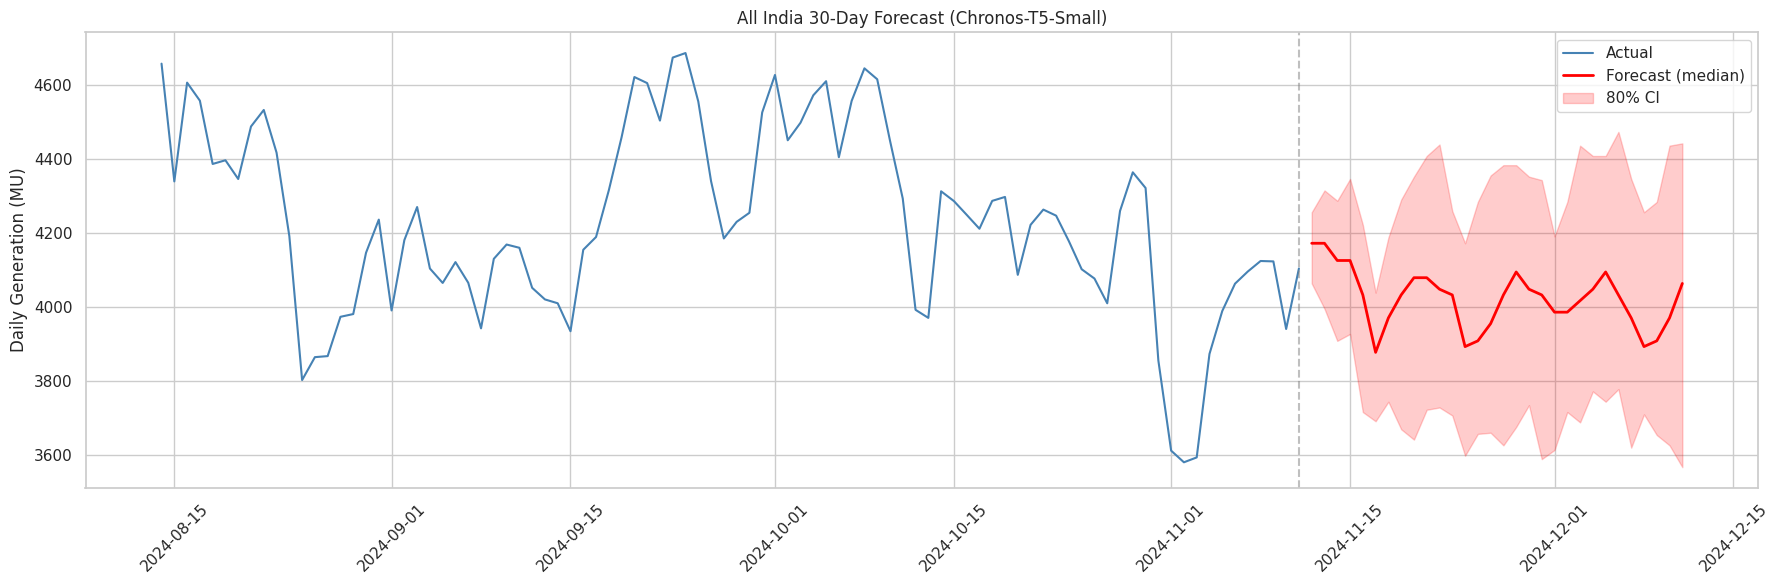

In [0]:
"""ts_data = daily_india.sort_values("date")["total_gen_actual"].values
context = torch.tensor(ts_data, dtype=torch.float32)

PREDICTION_LENGTH = 30

#forecast = pipeline.predict(context=context, prediction_length=PREDICTION_LENGTH, num_samples=20)
forecast = pipeline.predict(inputs=context, prediction_length=PREDICTION_LENGTH, num_samples=20)

forecast_median = forecast.median(dim=1).squeeze().numpy()
forecast_low = forecast.quantile(0.1, dim=1).squeeze().numpy()
forecast_high = forecast.quantile(0.9, dim=1).squeeze().numpy()

last_date = daily_india["date"].max()
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=PREDICTION_LENGTH)
"""
# Plot
"""
fig, ax = plt.subplots(figsize=(18, 6))

recent = daily_india.sort_values("date").tail(90)
ax.plot(recent["date"], recent["total_gen_actual"], color="steelblue", linewidth=1.5, label="Actual")
ax.plot(forecast_dates, forecast_median, color="red", linewidth=2, label="Chronos Forecast (median)")
ax.fill_between(forecast_dates, forecast_low, forecast_high, alpha=0.2, color="red", label="95% CI")#80% 
ax.axvline(x=last_date, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Daily Generation (MU)")
ax.set_title("All India Power Generation — 30-Day Forecast (Chronos-T5-Small)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
"""

fig, ax = plt.subplots(figsize=(18, 6))
recent = daily_india.sort_values("date").tail(90)
ax.plot(recent["date"], recent["total_gen_actual"], color="steelblue", label="Actual")
ax.plot(pred_df["timestamp"], pred_df["0.5"], color="red", linewidth=2, label="Forecast (median)")
ax.fill_between(pred_df["timestamp"], pred_df["0.1"], pred_df["0.9"], alpha=0.2, color="red", label="80% CI")
ax.axvline(x=recent["date"].max(), color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Daily Generation (MU)")
ax.set_title("All India 30-Day Forecast (Chronos-T5-Small)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5a.a Train-test splitting

Train: 2017-09-01 → 2024-02-22 (2366 days)
Test:  2024-02-23 → 2024-04-26 (64 days)

📊 Conventional Generation Backtest:
  MAE:  285.26 MU
  RMSE: 322.89 MU
  MAPE: 6.53%


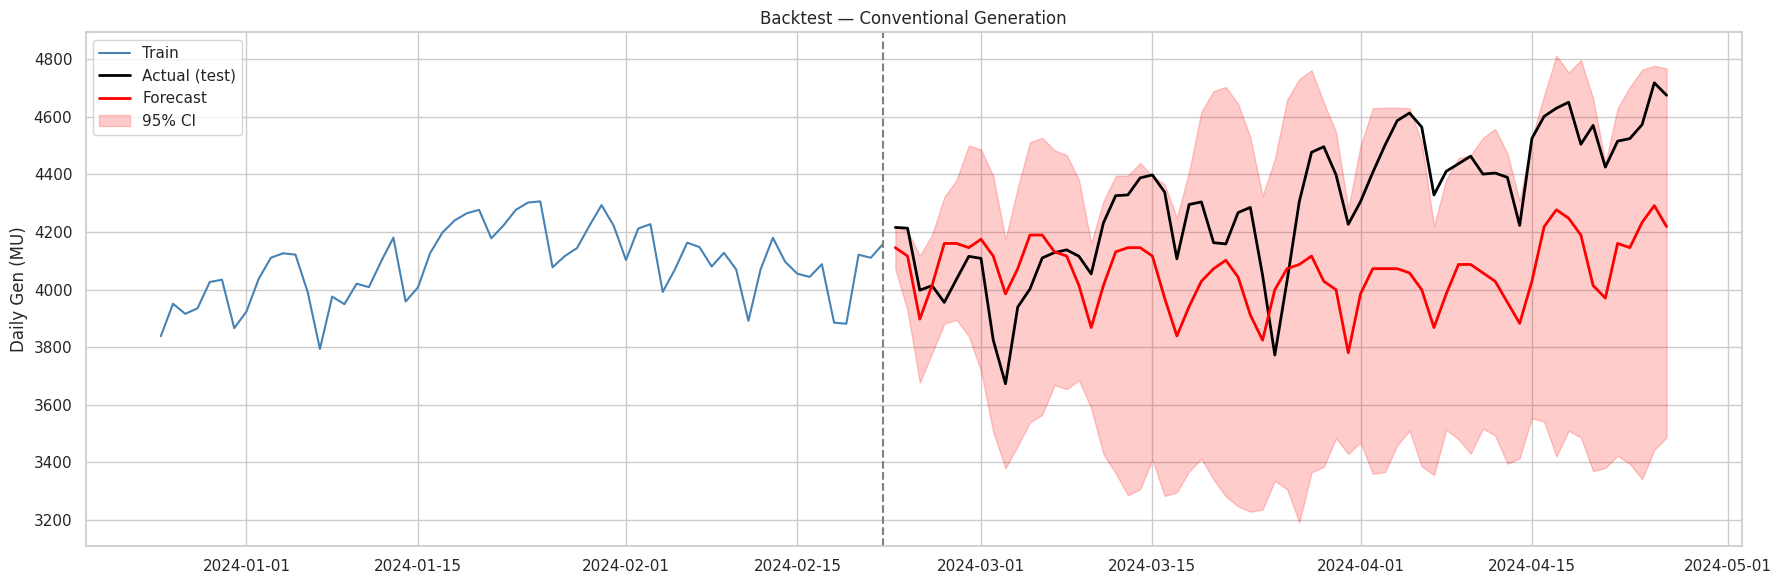

In [0]:
split_idx = int(len(ts_df) * 0.9)
train_df = ts_df.iloc[:split_idx].copy()
test_df = ts_df.iloc[split_idx:].copy()

# Cap at 64 as recommended
pred_length = min(len(test_df), 64)
test_df = test_df.iloc[:pred_length]

print(f"Train: {train_df.timestamp.min().date()} → {train_df.timestamp.max().date()} ({len(train_df)} days)")
print(f"Test:  {test_df.timestamp.min().date()} → {test_df.timestamp.max().date()} ({len(test_df)} days)")

pred_val = pipeline.predict_df(
    train_df,
    prediction_length=pred_length,
    quantile_levels=[0.025, 0.5, 0.975], #quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = test_df["target"].values
predicted = pred_val["0.5"].values[:len(test_df)]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = (abs(actual - predicted) / actual).mean() * 100

print(f"\n📊 Conventional Generation Backtest:")
print(f"  MAE:  {mae:.2f} MU")
print(f"  RMSE: {rmse:.2f} MU")
print(f"  MAPE: {mape:.2f}%")

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(train_df["timestamp"].tail(60), train_df["target"].tail(60), color="steelblue", label="Train")
ax.plot(test_df["timestamp"], test_df["target"], color="black", linewidth=2, label="Actual (test)")
ax.plot(pred_val["timestamp"], pred_val["0.5"], color="red", linewidth=2, label="Forecast")
ax.fill_between(pred_val["timestamp"], pred_val["0.025"], pred_val["0.975"], alpha=0.2, color="red", label="95% CI") #80% 
ax.axvline(x=train_df["timestamp"].max(), color="gray", linestyle="--")
ax.set_title("Backtest — Conventional Generation")
ax.set_ylabel("Daily Gen (MU)")
ax.legend()
plt.tight_layout()
plt.show()

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


Train: 2017-09-01 → 2024-02-22 (2366 days)
Test:  2024-02-23 → 2024-11-11 (263 days)

📊 Conventional Generation Backtest:
  MAE:  312.54 MU
  RMSE: 376.23 MU
  MAPE: 7.19%


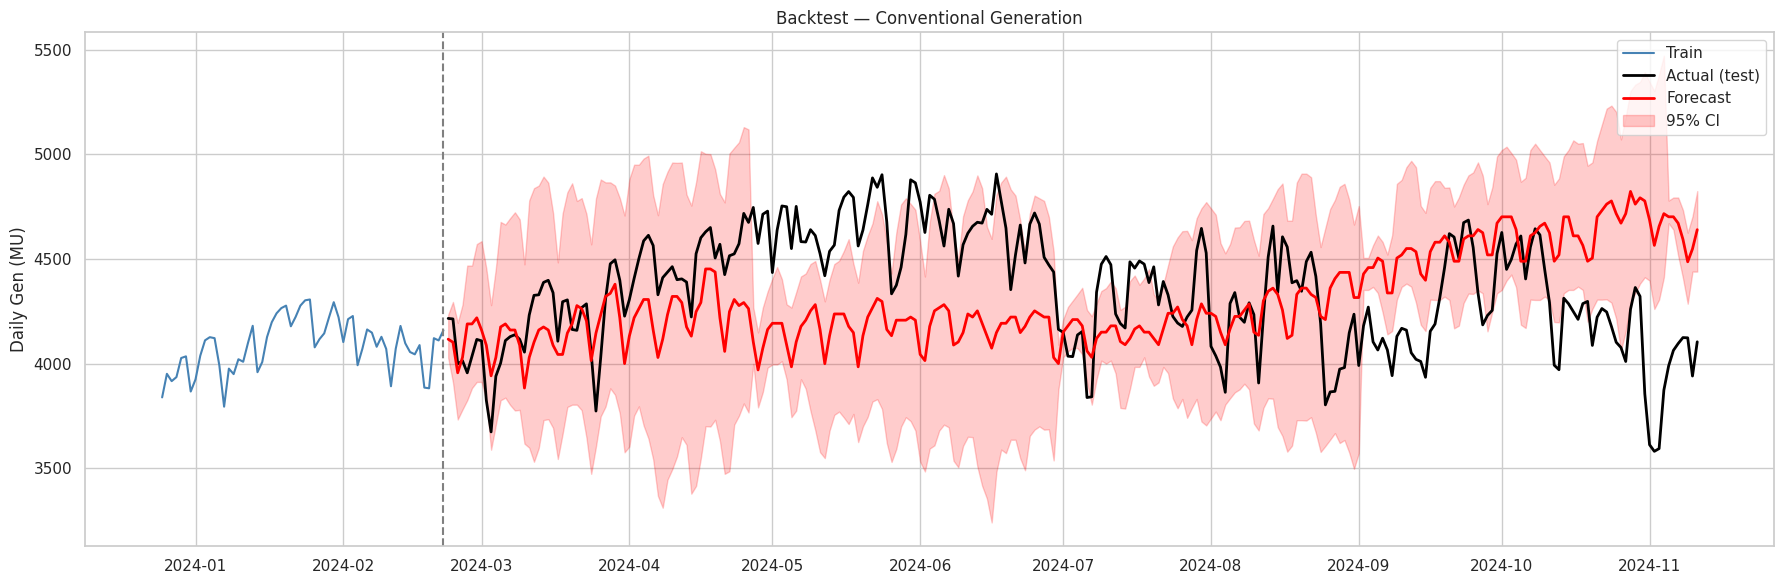

In [0]:
# ========================================
# BACKTEST VALIDATION — All India Conventional
# ========================================
split_idx = int(len(ts_df) * 0.9)
train_df = ts_df.iloc[:split_idx].copy()
test_df = ts_df.iloc[split_idx:].copy()

print(f"Train: {train_df.timestamp.min().date()} → {train_df.timestamp.max().date()} ({len(train_df)} days)")
print(f"Test:  {test_df.timestamp.min().date()} → {test_df.timestamp.max().date()} ({len(test_df)} days)")

pred_val = pipeline.predict_df(
    train_df,
    prediction_length=len(test_df),
    quantile_levels=[0.025, 0.5, 0.975], # quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = test_df["target"].values
predicted = pred_val["0.5"].values[:len(test_df)]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = (abs(actual - predicted) / actual).mean() * 100

print(f"\n📊 Conventional Generation Backtest:")
print(f"  MAE:  {mae:.2f} MU")
print(f"  RMSE: {rmse:.2f} MU")
print(f"  MAPE: {mape:.2f}%")

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(train_df["timestamp"].tail(60), train_df["target"].tail(60), color="steelblue", label="Train")
ax.plot(test_df["timestamp"], test_df["target"], color="black", linewidth=2, label="Actual (test)")
ax.plot(pred_val["timestamp"], pred_val["0.5"], color="red", linewidth=2, label="Forecast")
ax.fill_between(pred_val["timestamp"], pred_val["0.025"], pred_val["0.975"], alpha=0.2, color="red", label="95% CI")
ax.axvline(x=train_df["timestamp"].max(), color="gray", linestyle="--")
ax.set_title("Backtest — Conventional Generation")
ax.set_ylabel("Daily Gen (MU)")
ax.legend()
plt.tight_layout()
plt.show()

## 5.a.b Renewable energy backtesting

Renewable series: 2019-11-01 → 2024-11-11 (1838 days)
Train: 2019-11-01 → 2024-05-11 (1654 days)
Test:  2024-05-12 → 2024-07-14 (64 days)

📊 Renewable Generation Backtest:
  MAE:  124.04 MU
  RMSE: 166.12 MU
  MAPE: 15.28%


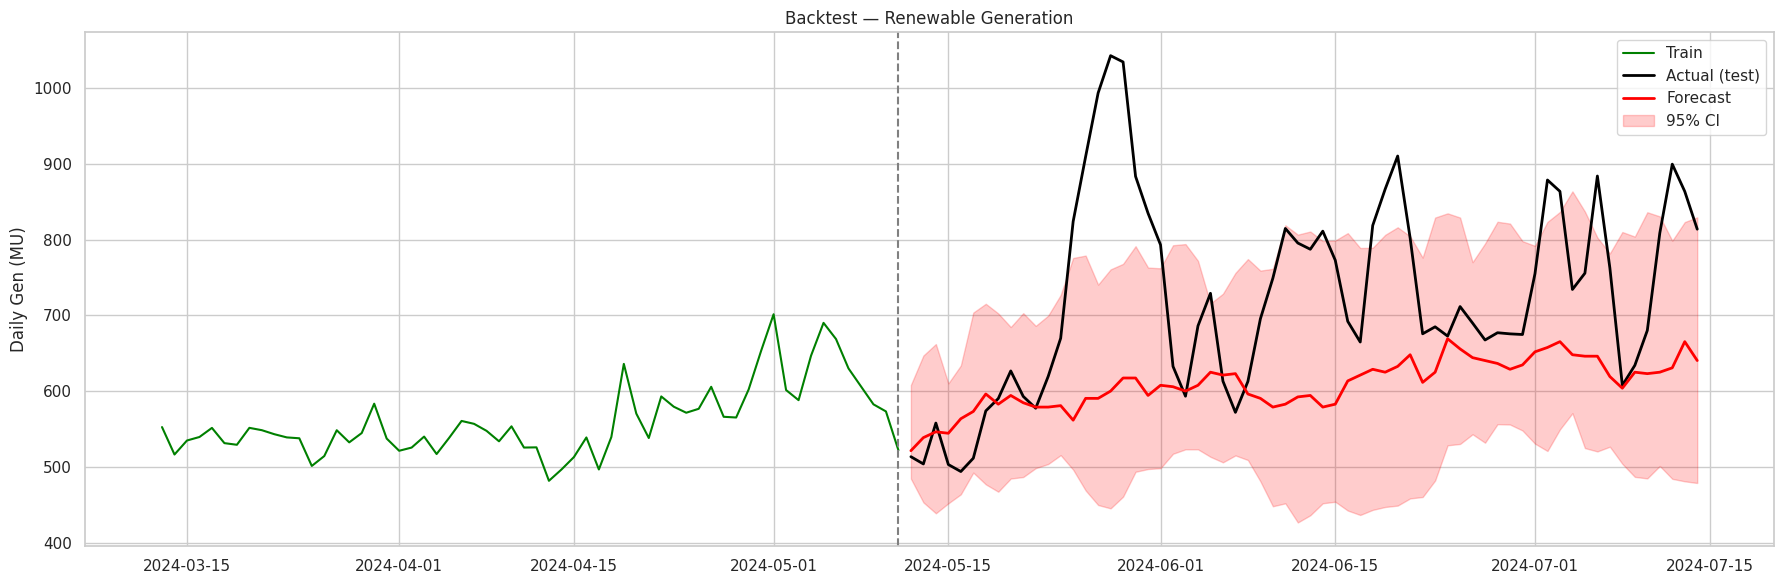

In [0]:
# ========================================
# RENEWABLE — Prep + Backtest
# ========================================
re_india = daily_india[["date", "total_renewable_energy"]].dropna().rename(
    columns={"date": "timestamp", "total_renewable_energy": "target"}
)
re_india["timestamp"] = pd.to_datetime(re_india["timestamp"])
re_india = re_india.sort_values("timestamp")
re_india = re_india.set_index("timestamp").asfreq("D").reset_index()
re_india["target"] = re_india["target"].interpolate()
re_india["id"] = "all_india_renewable"

print(f"Renewable series: {re_india.timestamp.min().date()} → {re_india.timestamp.max().date()} ({len(re_india)} days)")

# Split
re_split = int(len(re_india) * 0.9)
re_train = re_india.iloc[:re_split].copy()
re_test = re_india.iloc[re_split:].copy()

re_pred_length = min(len(re_test), 64)
re_test = re_test.iloc[:re_pred_length]

print(f"Train: {re_train.timestamp.min().date()} → {re_train.timestamp.max().date()} ({len(re_train)} days)")
print(f"Test:  {re_test.timestamp.min().date()} → {re_test.timestamp.max().date()} ({len(re_test)} days)")

re_pred_val = pipeline.predict_df(
    re_train,
    prediction_length=re_pred_length,
    quantile_levels=[0.025, 0.5, 0.975],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

re_actual = re_test["target"].values
re_predicted = re_pred_val["0.5"].values[:len(re_test)]

re_mae = mean_absolute_error(re_actual, re_predicted)
re_rmse = np.sqrt(mean_squared_error(re_actual, re_predicted))
re_mape = (abs(re_actual - re_predicted) / re_actual.clip(min=0.01)).mean() * 100

print(f"\n📊 Renewable Generation Backtest:")
print(f"  MAE:  {re_mae:.2f} MU")
print(f"  RMSE: {re_rmse:.2f} MU")
print(f"  MAPE: {re_mape:.2f}%")

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(re_train["timestamp"].tail(60), re_train["target"].tail(60), color="green", label="Train")
ax.plot(re_test["timestamp"], re_test["target"], color="black", linewidth=2, label="Actual (test)")
ax.plot(re_pred_val["timestamp"], re_pred_val["0.5"], color="red", linewidth=2, label="Forecast")
ax.fill_between(re_pred_val["timestamp"], re_pred_val["0.025"], re_pred_val["0.975"], alpha=0.2, color="red", label="95% CI")
ax.axvline(x=re_train["timestamp"].max(), color="gray", linestyle="--")
ax.set_title("Backtest — Renewable Generation")
ax.set_ylabel("Daily Gen (MU)")
ax.legend()
plt.tight_layout()
plt.show()

## 5.a.c Combined view: convntional + renewable

In [0]:
re_forecast = pipeline.predict_df(
    re_india,
    prediction_length=30,
    quantile_levels=[0.025, 0.5, 0.975],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

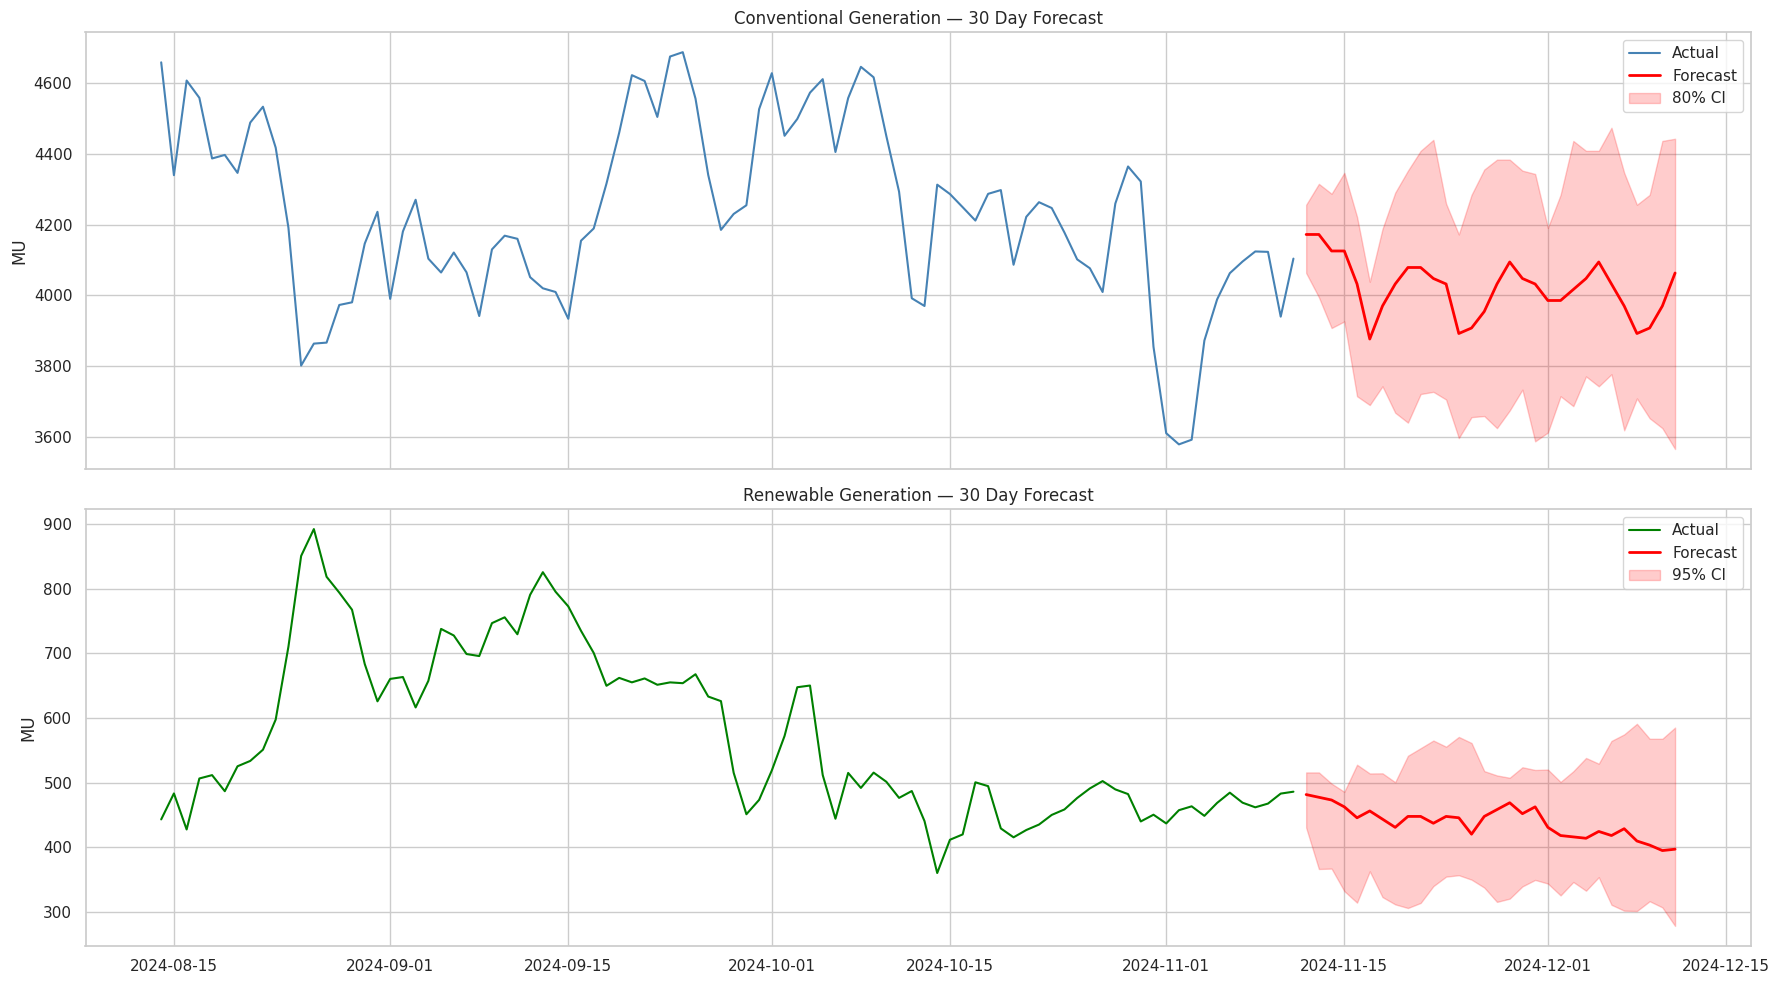

In [0]:
# ========================================
# COMBINED VIEW — Conv + Renewable forecasts
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Conventional
axes[0].plot(daily_india["date"].tail(90), daily_india["total_gen_actual"].tail(90), color="steelblue", label="Actual")
axes[0].plot(pred_df["timestamp"], pred_df["0.5"], color="red", linewidth=2, label="Forecast")
axes[0].fill_between(pred_df["timestamp"], pred_df["0.1"], pred_df["0.9"], alpha=0.2, color="red", label="80% CI")
axes[0].set_ylabel("MU")
axes[0].set_title("Conventional Generation — 30 Day Forecast")
axes[0].legend()

# Renewable
axes[1].plot(re_india["timestamp"].tail(90), re_india["target"].tail(90), color="green", label="Actual")
axes[1].plot(re_forecast["timestamp"], re_forecast["0.5"], color="red", linewidth=2, label="Forecast")
axes[1].fill_between(re_forecast["timestamp"], re_forecast["0.025"], re_forecast["0.975"], alpha=0.2, color="red", label="95% CI")
axes[1].set_ylabel("MU")
axes[1].set_title("Renewable Generation — 30 Day Forecast")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5b. State-level Forecast (Maharashtra)

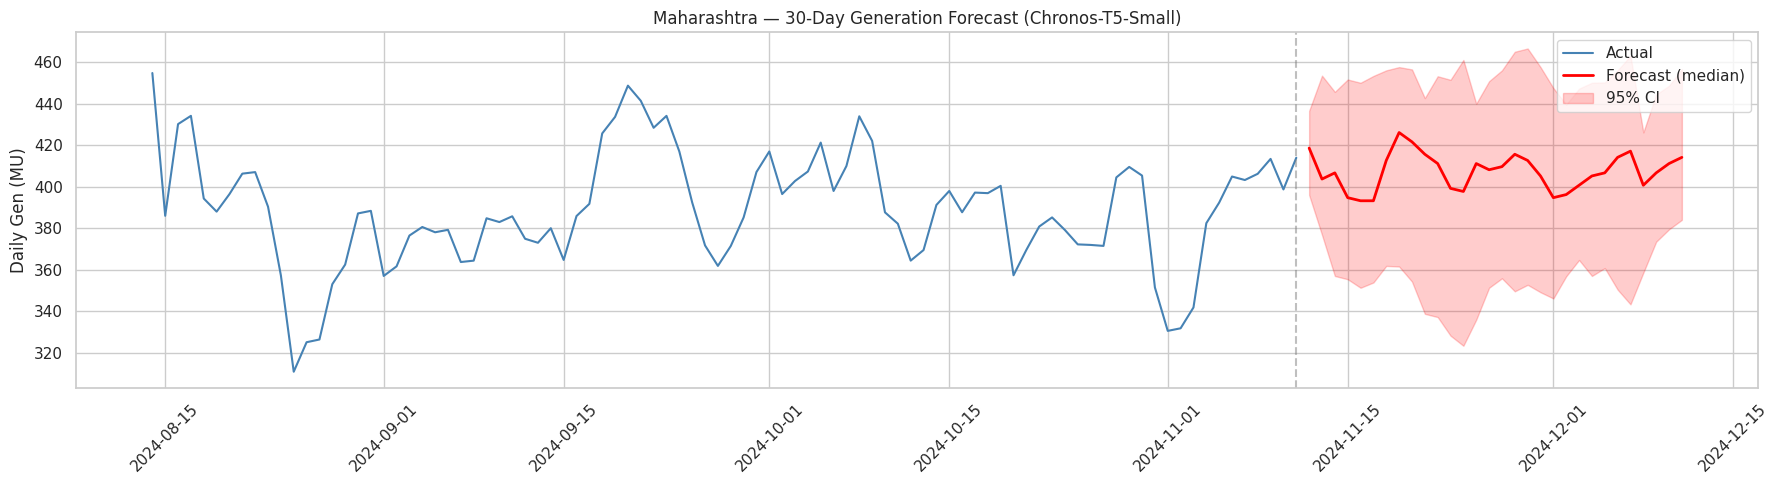

In [0]:
TARGET_STATE = "Maharashtra"

state_ts = daily_state[daily_state["state_name"] == TARGET_STATE][["date", "gen_actual"]].rename(
    columns={"date": "timestamp", "gen_actual": "target"}
)
state_ts["timestamp"] = pd.to_datetime(state_ts["timestamp"])
state_ts = state_ts.sort_values("timestamp")
state_ts = state_ts.set_index("timestamp").asfreq("D").reset_index()
state_ts["target"] = state_ts["target"].interpolate()
state_ts["id"] = TARGET_STATE

pred_state = pipeline.predict_df(
    state_ts,
    prediction_length=30,
    quantile_levels=[0.025, 0.5, 0.975], #quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

fig, ax = plt.subplots(figsize=(18, 5))
recent_st = state_ts.tail(90)
ax.plot(recent_st["timestamp"], recent_st["target"], color="steelblue", linewidth=1.5, label="Actual")
ax.plot(pred_state["timestamp"], pred_state["0.5"], color="red", linewidth=2, label="Forecast (median)")
ax.fill_between(pred_state["timestamp"], pred_state["0.025"], pred_state["0.975"], alpha=0.2, color="red", label="95% CI")
ax.axvline(x=recent_st["timestamp"].max(), color="gray", linestyle="--", alpha=0.5)
ax.set_title(f"{TARGET_STATE} — 30-Day Generation Forecast (Chronos-T5-Small)")
ax.set_ylabel("Daily Gen (MU)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Save Processed Data (for Graph Notebook)

In [0]:
# Save all processed dataframes for next notebook
daily_india.to_csv("processed_daily_india.csv", index=False)
daily_state.to_csv("processed_daily_state.csv", index=False)
station_summary.to_csv("processed_station_summary.csv", index=False)
ds.to_csv("processed_demand_supply.csv", index=False)
 
print("✅ Saved processed CSVs for graph notebook:")
print("  - processed_daily_india.csv")
print("  - processed_daily_state.csv")
print("  - processed_station_summary.csv")
print("  - processed_demand_supply.csv")


✅ Saved processed CSVs for graph notebook:
  - processed_daily_india.csv
  - processed_daily_state.csv
  - processed_station_summary.csv
  - processed_demand_supply.csv
